In [24]:
import torch
import pandas as pd
import torch.nn.functional as F

# load embedding
data = torch.load("data/article_embeddings_hgnn3.pt")
emb = data["embeddings"]
id2idx = data["id2idx"]

# normalize (QUAN TRỌNG)
emb = F.normalize(emb, dim=1)

# load split
train_df = pd.read_csv("data/train_split.csv")
test_df = pd.read_csv("data/test_split.csv")

# đảm bảo format giống nhau
train_df["article_id"] = train_df["article_id"].astype(str).str.zfill(10)
test_df["article_id"] = test_df["article_id"].astype(str).str.zfill(10)

print("Train:", len(train_df))
print("Test:", len(test_df))

Train: 216048
Test: 29288


In [25]:
from collections import defaultdict

user_hist = defaultdict(list)

for _, row in train_df.iterrows():
    user_hist[row["customer_id"]].append(row["article_id"])

print("Num users:", len(user_hist))

Num users: 54987


In [26]:
idx2id = {v: k for k, v in id2idx.items()}

In [27]:
def recommend(user_items, emb, id2idx, idx2id, K=10):
    # 🔥 chỉ lấy last N items
    user_items = user_items[-5:]   # QUAN TRỌNG

    vecs = []
    for item in user_items:
        if item in id2idx:
            vecs.append(emb[id2idx[item]])

    if len(vecs) == 0:
        return []

    user_emb = torch.stack(vecs).mean(dim=0)

    scores = torch.matmul(emb, user_emb)

    # remove seen
    seen = set(user_items)

    topk = torch.topk(scores, k=K + len(seen)).indices

    results = []
    for i in topk:
        aid = idx2id[i.item()]
        if aid not in seen:
            results.append(aid)
        if len(results) == K:
            break

    return results

In [28]:
import math

def evaluate(test_df, user_hist, emb, id2idx, idx2id, K=10):
    hits = 0
    ndcg = 0
    total = 0

    for _, row in test_df.iterrows():
        user = row["customer_id"]
        true_item = row["article_id"]

        if user not in user_hist:
            continue

        preds = recommend(user_hist[user], emb, id2idx, idx2id, K)

        if len(preds) == 0:
            continue

        # Recall / Hit
        if true_item in preds:
            hits += 1

            rank = preds.index(true_item)
            ndcg += 1 / math.log2(rank + 2)

        total += 1

    return {
        f"Recall@{K}": hits / total,
        f"NDCG@{K}": ndcg / total
    }

In [29]:
for k in [5, 10, 20]:
    result = evaluate(test_df, user_hist, emb, id2idx, idx2id, K=k)
    print(result)

{'Recall@5': 0.0015240583496625298, 'NDCG@5': 0.0008907544044800822}
{'Recall@10': 0.003919007184846506, 'NDCG@10': 0.001664724924440646}
{'Recall@20': 0.00762029174831265, 'NDCG@20': 0.0026022297908755787}


In [30]:
missing = sum(1 for _, row in test_df.iterrows() 
              if row["article_id"] not in id2idx)

print("Missing ratio:", missing / len(test_df))

Missing ratio: 0.0


In [49]:
import torch
import random
from torch.nn.functional import normalize

def evaluate_mlp(model, clip_embeddings, hgnn_embeddings, id2idx, k=10, n_samples=1000, device="cuda"):
    """
    Evaluate Student MLP bằng recall@k trên random sample.
    """
    model = model.to(device)
    model.eval()

    all_ids = list(clip_embeddings.keys())
    sampled_ids = random.sample(all_ids, min(n_samples, len(all_ids)))

    recalls = []
    with torch.no_grad():
        # chuẩn hóa toàn bộ HGNN embeddings
        hgnn_norm = normalize(hgnn_embeddings.to(device), dim=1)

        for aid in sampled_ids:
            clip_vec = clip_embeddings[aid].to(device)
            pred_vec = normalize(model(clip_vec.unsqueeze(0)), dim=1)  # [1, D]

            sims = torch.matmul(pred_vec, hgnn_norm.T)  # [1, N]
            topk_idx = sims.topk(k, dim=1).indices.squeeze(0)

            true_idx = id2idx[aid]
            recalls.append(1 if true_idx in topk_idx else 0)

    recall_at_k = sum(recalls) / len(recalls)
    print(f"Recall@{k} trên {len(sampled_ids)} samples: {recall_at_k:.4f}")
    return recall_at_k

In [59]:
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from torch.nn.functional import normalize
import random
import numpy as np

def visualize_embeddings(model, clip_embeddings, hgnn_embeddings, id2idx, n_samples=500, device="cuda"):
    """
    Visualize quality of Student MLP predictions.
    
    - t-SNE plot: predicted vs true HGNN embeddings
    - Histogram of cosine similarity
    """
    model = model.to(device)
    model.eval()

    all_ids = list(clip_embeddings.keys())
    sampled_ids = random.sample(all_ids, min(n_samples, len(all_ids)))

    preds = []
    trues = []

    with torch.no_grad():
        for aid in sampled_ids:
            clip_vec = clip_embeddings[aid].to(device)
            pred_vec = normalize(model(clip_vec.unsqueeze(0)), dim=1).cpu()
            true_vec = normalize(hgnn_embeddings[id2idx[aid]].unsqueeze(0), dim=1).cpu()

            preds.append(pred_vec.squeeze(0))
            trues.append(true_vec.squeeze(0))

    preds = torch.stack(preds).numpy()
    trues = torch.stack(trues).numpy()

    # Histogram cosine similarity
    cos_sim = (preds * trues).sum(axis=1)  # since normalized
    plt.figure(figsize=(6,4))
    plt.hist(cos_sim, bins=30, color='skyblue')
    plt.title("Cosine similarity between predicted & true HGNN embeddings")
    plt.xlabel("Cosine similarity")
    plt.ylabel("Count")
    plt.show()

    # t-SNE visualization
    tsne_input = torch.tensor(np.vstack([preds, trues])).numpy()
    tsne = TSNE(n_components=2, random_state=42)
    tsne_res = tsne.fit_transform(tsne_input)

    plt.figure(figsize=(6,6))
    plt.scatter(tsne_res[:n_samples,0], tsne_res[:n_samples,1], c='red', label='Predicted', alpha=0.6)
    plt.scatter(tsne_res[n_samples:,0], tsne_res[n_samples:,1], c='blue', label='True HGNN', alpha=0.6)
    plt.title("t-SNE of Predicted vs True HGNN Embeddings")
    plt.legend()
    plt.show()

Recall@10 trên 1000 samples: 0.4350


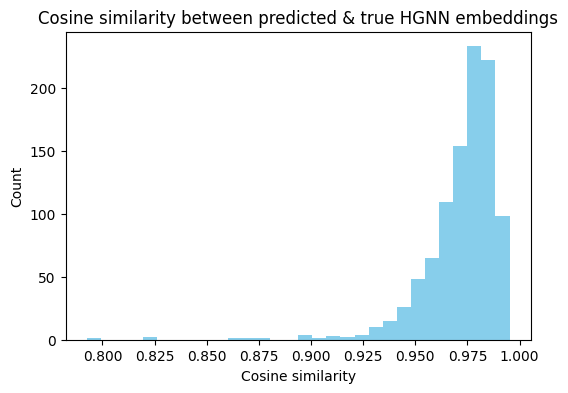

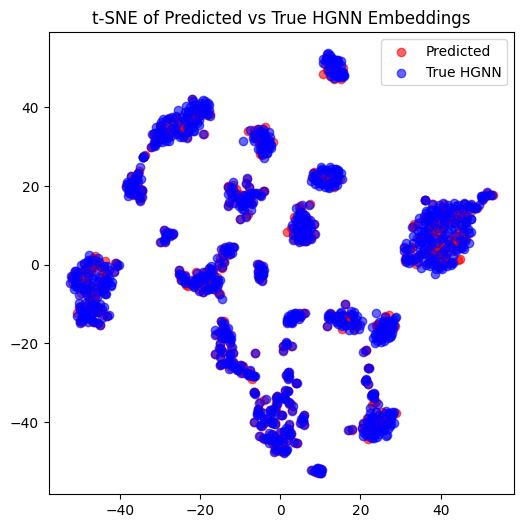

In [63]:
# Giả sử bạn đã load model và embeddings
import torch
from MLP_student.model import StudentMLP

device = "cuda" if torch.cuda.is_available() else "cpu"

model = StudentMLP(in_dim=512)
model.load_state_dict(torch.load("data/mlp_student.pt", map_location=torch.device(device)))
model.to(device)

# Load embeddings
clip_emb = torch.load("data/clip_embeddings.pt")
hgnn_data = torch.load("data/article_embeddings_hgnn3.pt")
hgnn_emb = hgnn_data["embeddings"]
id2idx = hgnn_data["id2idx"]

# Evaluate recall@10
evaluate_mlp(model, clip_emb, hgnn_emb, id2idx, k=10, n_samples=1000, device=device)
visualize_embeddings(
    model,
    clip_embeddings=clip_emb,
    hgnn_embeddings=hgnn_emb,
    id2idx=id2idx,
    n_samples=1000,
    device=device
)